# Multi-Model Test Inference

Notebook dùng để load *tất cả* mô hình đã huấn luyện (ARIMAX, SVR, Random Forest, Hybrid Prophet + LSTM) và đánh giá trực tiếp trên toàn bộ tập test. Các bước thực hiện:

1. Lấy mô hình mới nhất của từng loại từ thư mục `models/`
2. Chạy dự đoán một lượt trên toàn bộ tập test (không rolling horizon)
3. Đo thời gian infer, tính các metric (MAE, RMSE, MAPE, R²)
4. Vẽ biểu đồ trực quan để so sánh giữa các mô hình cho từng target



In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

from model_utils import (
    load_model,
    get_latest_model,
    calculate_metrics,
    print_metrics,
    save_results,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:,.6f}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Libraries imported (device={DEVICE})")


✓ Libraries imported (device=cpu)


In [2]:
# Paths & targets
MODELS_DIR = Path('models')
DATA_DIR = Path('processed_data')
TARGETS = ['memory_usage_pct', 'cpu_total_usage', 'system_load']
MODEL_TYPES = ['arimax', 'svr', 'random_forest', 'hybrid_prophet_lstm']
DEFAULT_FREQ = '30S'
WINDOW_FALLBACK = 96

MODELS_DIR.mkdir(exist_ok=True)

print("✓ Configuration ready")


✓ Configuration ready


In [3]:
def load_dataset(target: str):
    target_dir = DATA_DIR / target
    data = {
        'X_train': pd.read_csv(target_dir / 'X_train.csv'),
        'X_test': pd.read_csv(target_dir / 'X_test.csv'),
        'y_train': pd.read_csv(target_dir / 'y_train.csv').squeeze(),
        'y_test': pd.read_csv(target_dir / 'y_test.csv').squeeze(),
    }
    return data


class LSTMResidualModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


def forecast_residuals(model, seed_sequence, n_steps, window_size):
    model.eval()
    seq = seed_sequence.copy().tolist()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            window = torch.tensor(seq[-window_size:], dtype=torch.float32).view(1, window_size, 1).to(DEVICE)
            pred = model(window).cpu().item()
            preds.append(pred)
            seq.append(pred)
    return np.array(preds)


def inverse_scale(values, mean, std):
    return values * std + mean


In [4]:
def resolve_model_paths(model_types=MODEL_TYPES):
    resolved = {}
    for model_name in model_types:
        resolved[model_name] = {}
        for target in TARGETS:
            resolved[model_name][target] = get_latest_model(
                models_dir=str(MODELS_DIR),
                model_name=model_name,
                target=target,
            )
    return resolved


model_paths = resolve_model_paths()
model_paths


Importing plotly failed. Interactive plots will not work.


Latest model: models\arimax_memory_usage_pct_20251111_154333.pkl
Latest model: models\arimax_cpu_total_usage_20251111_154831.pkl
Latest model: models\arimax_system_load_20251111_155022.pkl
Latest model: models\svr_memory_usage_pct_20251111_184735.pkl
Latest model: models\svr_cpu_total_usage_20251111_203645.pkl
Latest model: models\svr_system_load_20251111_223919.pkl
Latest model: models\random_forest_memory_usage_pct_20251111_221757.pkl
Latest model: models\random_forest_cpu_total_usage_20251111_221930.pkl
Latest model: models\random_forest_system_load_20251111_221944.pkl
Latest model: models\hybrid_prophet_lstm_memory_usage_pct_20251125_115803.pkl
Latest model: models\hybrid_prophet_lstm_cpu_total_usage_20251125_121521.pkl
Latest model: models\hybrid_prophet_lstm_system_load_20251125_123017.pkl


{'arimax': {'memory_usage_pct': 'models\\arimax_memory_usage_pct_20251111_154333.pkl',
  'cpu_total_usage': 'models\\arimax_cpu_total_usage_20251111_154831.pkl',
  'system_load': 'models\\arimax_system_load_20251111_155022.pkl'},
 'svr': {'memory_usage_pct': 'models\\svr_memory_usage_pct_20251111_184735.pkl',
  'cpu_total_usage': 'models\\svr_cpu_total_usage_20251111_203645.pkl',
  'system_load': 'models\\svr_system_load_20251111_223919.pkl'},
 'random_forest': {'memory_usage_pct': 'models\\random_forest_memory_usage_pct_20251111_221757.pkl',
  'cpu_total_usage': 'models\\random_forest_cpu_total_usage_20251111_221930.pkl',
  'system_load': 'models\\random_forest_system_load_20251111_221944.pkl'},
 'hybrid_prophet_lstm': {'memory_usage_pct': 'models\\hybrid_prophet_lstm_memory_usage_pct_20251125_115803.pkl',
  'cpu_total_usage': 'models\\hybrid_prophet_lstm_cpu_total_usage_20251125_121521.pkl',
  'system_load': 'models\\hybrid_prophet_lstm_system_load_20251125_123017.pkl'}}

In [5]:
def evaluate_arimax(model_path, dataset):
    X_test = dataset['X_test']
    y_test = dataset['y_test']

    model, metadata = load_model(model_path)
    start_time = time.time()
    y_pred = model.forecast(steps=len(y_test), exog=X_test)
    runtime = time.time() - start_time

    y_pred = np.asarray(y_pred)
    metrics = calculate_metrics(y_test.values, y_pred)

    return {
        'y_pred': y_pred,
        'runtime': runtime,
        'metrics': metrics,
        'metadata': metadata,
    }


def evaluate_svr(model_path, dataset):
    X_test = dataset['X_test']
    y_test = dataset['y_test']

    model, metadata = load_model(model_path)
    start_time = time.time()
    y_pred = model.predict(X_test)
    runtime = time.time() - start_time

    metrics = calculate_metrics(y_test.values, y_pred)

    return {
        'y_pred': y_pred,
        'runtime': runtime,
        'metrics': metrics,
        'metadata': metadata,
    }


def evaluate_random_forest(model_path, dataset):
    X_test = dataset['X_test']
    y_test = dataset['y_test']

    model, metadata = load_model(model_path)
    start_time = time.time()
    y_pred = model.predict(X_test)
    runtime = time.time() - start_time

    metrics = calculate_metrics(y_test.values, y_pred)

    return {
        'y_pred': y_pred,
        'runtime': runtime,
        'metrics': metrics,
        'metadata': metadata,
    }


def evaluate_hybrid(model_path, dataset):
    y_train = dataset['y_train']
    y_test = dataset['y_test']

    model_bundle, metadata = load_model(model_path)
    prophet_model = model_bundle['prophet']
    lstm_state_dict = model_bundle['lstm_state_dict']
    residual_mean = model_bundle['residual_mean']
    residual_std = model_bundle['residual_std'] if model_bundle['residual_std'] > 0 else 1e-6
    window_size = model_bundle.get('window_size') or model_bundle.get('config', {}).get('lstm', {}).get('window_size', WINDOW_FALLBACK)
    freq = model_bundle.get('freq', DEFAULT_FREQ)
    lstm_cfg = model_bundle.get('config', {}).get('lstm', {})

    lstm_model = LSTMResidualModel(
        hidden_size=lstm_cfg.get('hidden_size', 64),
        num_layers=lstm_cfg.get('num_layers', 2),
        dropout=lstm_cfg.get('dropout', 0.1),
    ).to(DEVICE)
    lstm_model.load_state_dict(lstm_state_dict)
    lstm_model.eval()

    n_train = len(y_train)
    n_test = len(y_test)

    start_time = time.time()

    future_df = prophet_model.make_future_dataframe(periods=n_test, freq=freq)
    forecast_df = prophet_model.predict(future_df)
    prophet_preds = forecast_df['yhat'].values
    prophet_train_pred = prophet_preds[:n_train]
    prophet_test_pred = prophet_preds[-n_test:]

    train_residuals = y_train.values - prophet_train_pred
    residuals_scaled = (train_residuals - residual_mean) / residual_std

    if len(residuals_scaled) < window_size:
        raise ValueError(f"Not enough residual history ({len(residuals_scaled)}) for window_size={window_size}")

    seed_sequence = residuals_scaled[-window_size:]
    residual_test_scaled = forecast_residuals(lstm_model, seed_sequence, n_test, window_size)
    residual_test_pred = inverse_scale(residual_test_scaled, residual_mean, residual_std)
    hybrid_pred = prophet_test_pred + residual_test_pred

    runtime = time.time() - start_time

    metrics = calculate_metrics(y_test.values, hybrid_pred)

    return {
        'y_pred': hybrid_pred,
        'prophet_pred': prophet_test_pred,
        'residual_pred': residual_test_pred,
        'runtime': runtime,
        'metrics': metrics,
        'metadata': metadata,
    }



In [6]:
EVALUATORS = {
    'arimax': evaluate_arimax,
    'svr': evaluate_svr,
    'random_forest': evaluate_random_forest,
    'hybrid_prophet_lstm': evaluate_hybrid,
}



In [7]:
evaluation_records = []
detailed_results = {model: {} for model in MODEL_TYPES}
prediction_store = {model: {} for model in MODEL_TYPES}
metrics_store = {model: {} for model in MODEL_TYPES}

for target in TARGETS:
    print("\n" + "=" * 100)
    print(f"Target: {target}")
    print("=" * 100)

    dataset = load_dataset(target)
    y_test = dataset['y_test']

    for model_name in MODEL_TYPES:
        print(f"\n--- {model_name.upper()} ---")
        model_path = model_paths[model_name][target]
        evaluator = EVALUATORS[model_name]

        result = evaluator(model_path, dataset)
        runtime = result['runtime']
        per_sample_ms = runtime / len(y_test) * 1000
        metrics = result['metrics']

        print_metrics(metrics, f"{target} ({model_name})")
        print(f"  Runtime: {runtime:.2f}s ({per_sample_ms:.3f} ms/sample)")

        evaluation_records.append({
            'model': model_name,
            'target': target,
            'model_path': model_path,
            'samples': len(y_test),
            'runtime_s': runtime,
            'ms_per_sample': per_sample_ms,
            **metrics,
        })

        detailed_results[model_name][target] = {
            'model_path': model_path,
            'runtime_seconds': runtime,
            'ms_per_sample': per_sample_ms,
            'metrics': metrics,
            'metadata': result['metadata'],
        }

        prediction_store[model_name][target] = {
            'y_pred': result['y_pred'],
            'y_true': y_test.values,
        }

        if model_name == 'hybrid_prophet_lstm':
            prediction_store[model_name][target]['prophet_pred'] = result['prophet_pred']
            prediction_store[model_name][target]['residual_pred'] = result['residual_pred']

        metrics_store[model_name][target] = metrics

print("\n✓ Evaluation completed for all models")



Target: memory_usage_pct

--- ARIMAX ---
✓ Model loaded: models\arimax_memory_usage_pct_20251111_154333.pkl
  Model: arimax
  Target: memory_usage_pct
  Saved at: 2025-11-11 15:43:33

Metrics for memory_usage_pct (arimax):
  MAE:         3.734215
  RMSE:        4.218339
  MAPE:        911.84%
  R²:          -21.727432
  Max Error:   7.118625
  Median AE:   3.863028
  Runtime: 0.65s (0.038 ms/sample)

--- SVR ---
✓ Model loaded: models\svr_memory_usage_pct_20251111_184735.pkl
  Model: svr
  Target: memory_usage_pct
  Saved at: 2025-11-11 18:47:35

Metrics for memory_usage_pct (svr):
  MAE:         0.416941
  RMSE:        0.547361
  MAPE:        143.18%
  R²:          0.617338
  Max Error:   5.737465
  Median AE:   0.329312
  Runtime: 93.63s (5.459 ms/sample)

--- RANDOM_FOREST ---
✓ Model loaded: models\random_forest_memory_usage_pct_20251111_221757.pkl
  Model: random_forest
  Target: memory_usage_pct
  Saved at: 2025-11-11 22:17:57

Metrics for memory_usage_pct (random_forest):
  MAE

In [8]:
summary_df = pd.DataFrame(evaluation_records)
summary_df.set_index(['target', 'model'], inplace=True)
summary_df


model_path  \
target           model                                                                    
memory_usage_pct arimax               models\arimax_memory_usage_pct_20251111_154333...   
                 svr                    models\svr_memory_usage_pct_20251111_184735.pkl   
                 random_forest        models\random_forest_memory_usage_pct_20251111...   
                 hybrid_prophet_lstm  models\hybrid_prophet_lstm_memory_usage_pct_20...   
cpu_total_usage  arimax               models\arimax_cpu_total_usage_20251111_154831.pkl   
                 svr                     models\svr_cpu_total_usage_20251111_203645.pkl   
                 random_forest        models\random_forest_cpu_total_usage_20251111_...   
                 hybrid_prophet_lstm  models\hybrid_prophet_lstm_cpu_total_usage_202...   
system_load      arimax                   models\arimax_system_load_20251111_155022.pkl   
                 svr                         models\svr_system_load_20251111_223919.pkl   
                 random_forest        models\random_forest_system_load_20251111_2219...   
                 hybrid_prophet_lstm  models\hybrid_prophet_lstm_system_load_2025112...   

                                      samples  runtime_s  ms_per_sample  \
target           model                                                    
memory_usage_pct arimax                 17150   0.650381       0.037923   
                 svr                    17150  93.625023       5.459185   
                 random_forest          17150   0.034967       0.002039   
                 hybrid_prophet_lstm    17150  59.069923       3.444310   
cpu_total_usage  arimax                 17150   0.688728       0.040159   
                 svr                    17150  26.459271       1.542815   
                 random_forest          17150   0.166278       0.009696   
                 hybrid_prophet_lstm    17150  43.460845       2.534160   
system_load      arimax                 17150   0.659701       0.038467   
                 svr                    17150  90.731419       5.290462   
                 random_forest          17150   0.029705       0.001732   
                 hybrid_prophet_lstm    17150  63.680854       3.713169   

                                          mae     rmse       mse         mape  \
target           model                                                          
memory_usage_pct arimax              3.734215 4.218339 17.794386   911.840416   
                 svr                 0.416941 0.547361  0.299604   143.178090   
                 random_forest       0.975521 1.096536  1.202391   233.711757   
                 hybrid_prophet_lstm 3.055926 3.337395 11.138206   672.508119   
cpu_total_usage  arimax              0.301637 0.794691  0.631534   105.067131   
                 svr                 0.193895 0.505259  0.255287    68.155849   
                 random_forest       0.170615 0.445639  0.198594    80.382009   
                 hybrid_prophet_lstm 1.544440 1.715171  2.941812   597.327753   
system_load      arimax              1.380341 1.792193  3.211954 2,399.639228   
                 svr                 0.268074 0.478303  0.228774   452.801162   
                 random_forest       0.263321 0.467283  0.218353   458.176250   
                 hybrid_prophet_lstm 0.646504 1.010859  1.021836   368.406446   

                                             r2  max_error  median_ae  
target           model                                                 
memory_usage_pct arimax              -21.727432   7.118625   3.863028  
                 svr                   0.617338   5.737465   0.329312  
                 random_forest        -0.535724   5.531988   1.161047  
                 hybrid_prophet_lstm -13.225993   5.605828   2.886380  
cpu_total_usage  arimax                0.339684  20.587866   0.151985  
                 svr                   0.733078  11.357502   0.074404  
                 random_forest         0

## Visualization


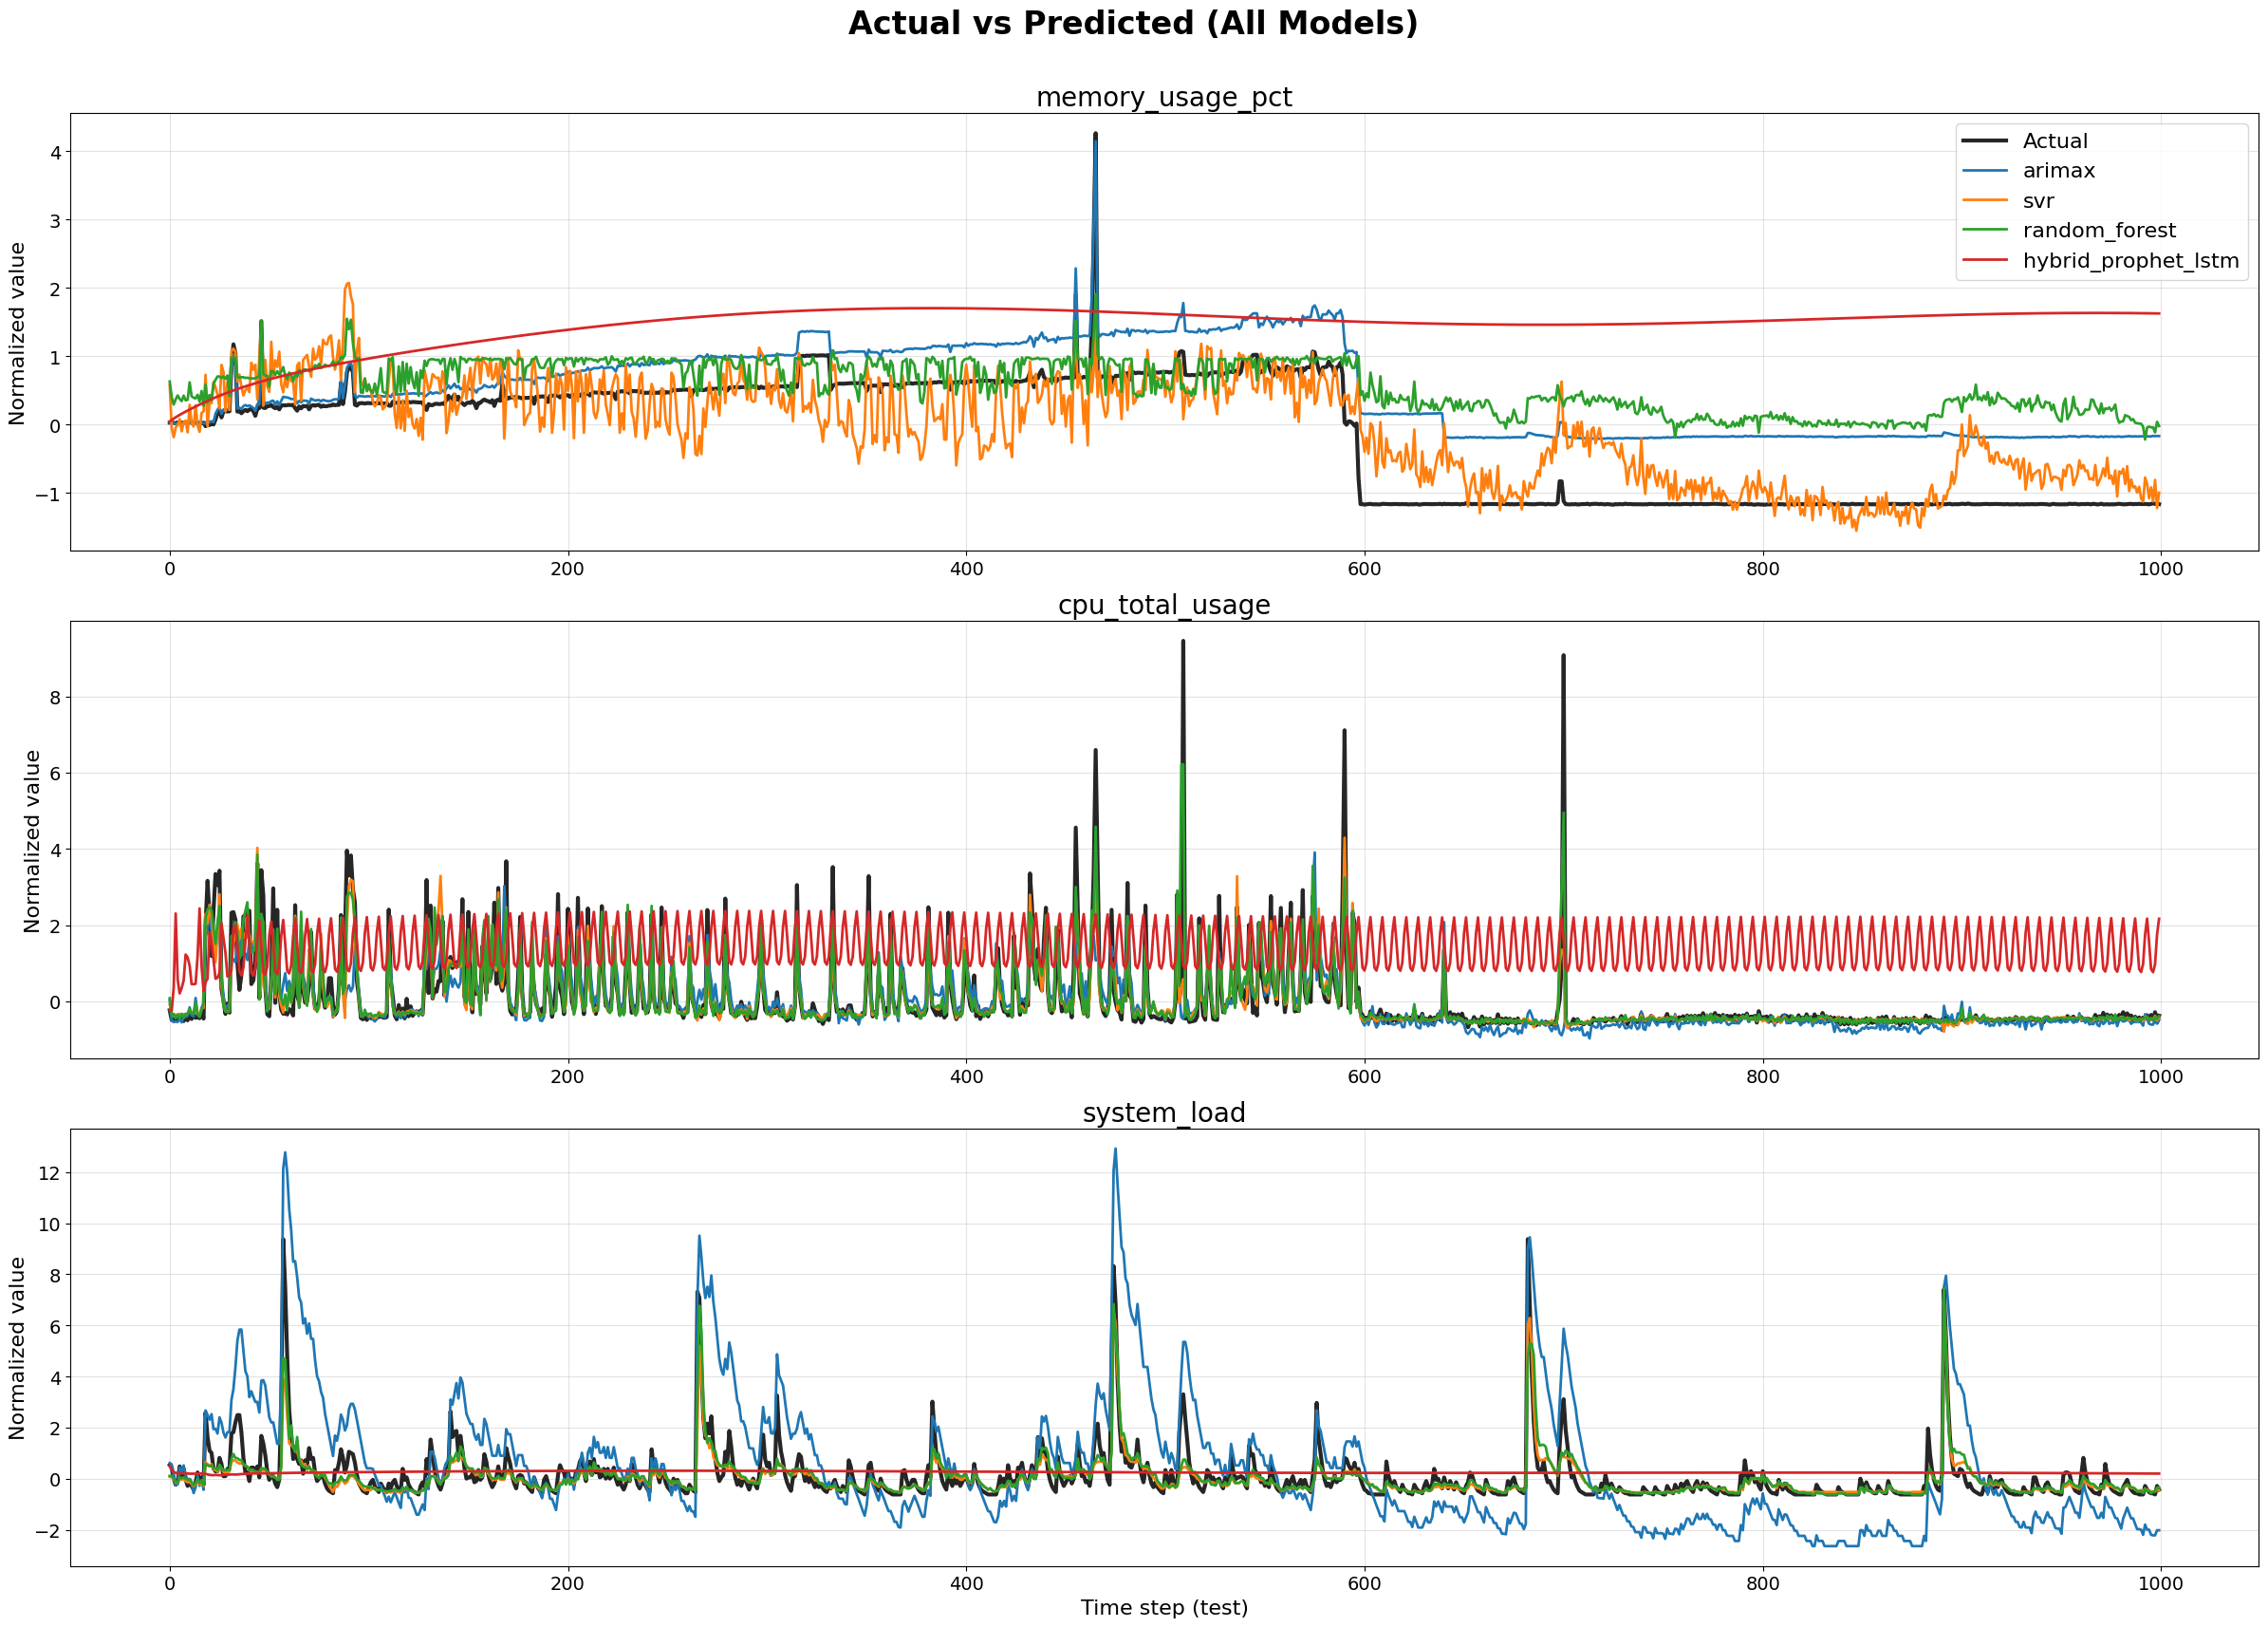

In [16]:
# Make the chart bigger for better visibility
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(24, 18), sharex=False)
fig.suptitle('Actual vs Predicted (All Models)', fontsize=24, fontweight='bold')

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    sample_model = MODEL_TYPES[0]
    y_true = prediction_store[sample_model][target]['y_true']
    n_plot = min(1000, len(y_true))

    ax.plot(y_true[:n_plot], label='Actual', linewidth=3, alpha=0.85, color='black')

    for model_name in MODEL_TYPES:
        preds = prediction_store[model_name][target]['y_pred']
        ax.plot(preds[:n_plot], label=model_name, linewidth=2)

    ax.set_title(target, fontsize=20)
    ax.set_ylabel('Normalized value', fontsize=16)
    ax.grid(True, alpha=0.35)
    if idx == len(TARGETS) - 1:
        ax.set_xlabel('Time step (test)', fontsize=16)
    if idx == 0:
        # New legend settings for bigger chart
        ax.legend(fontsize=16, loc='upper right')

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


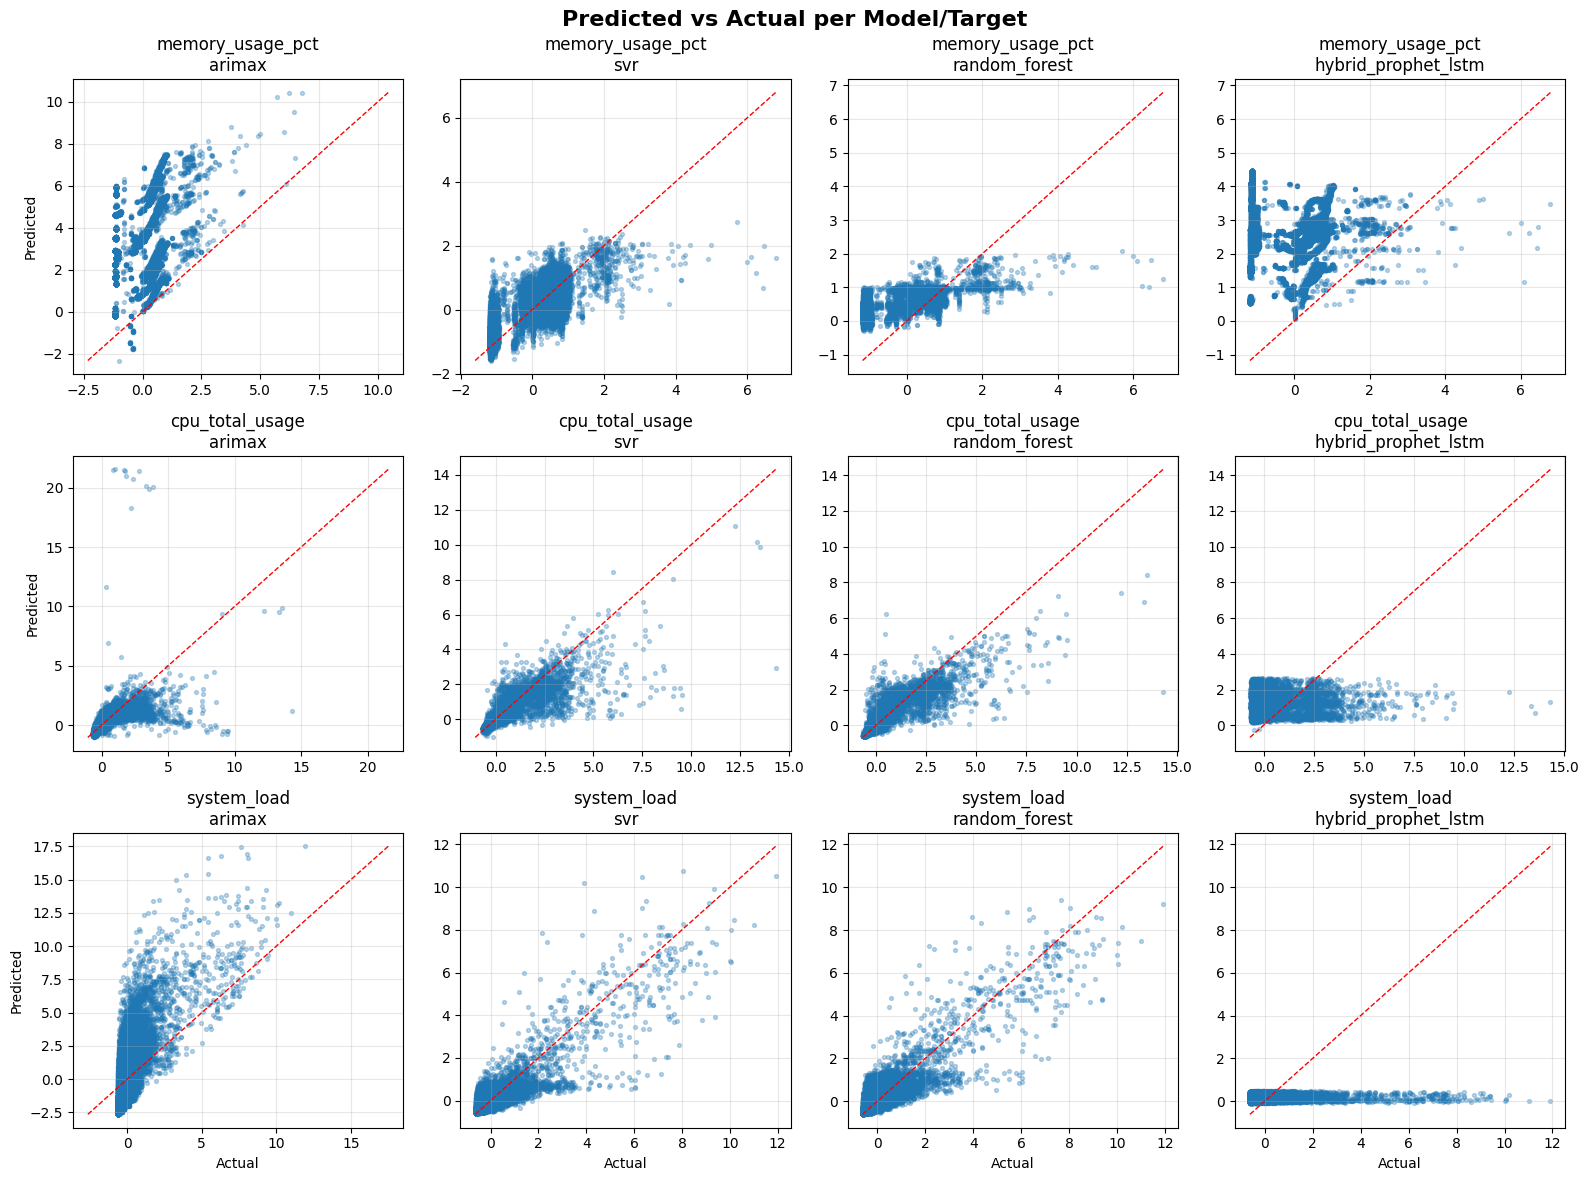

In [10]:
fig, axes = plt.subplots(len(TARGETS), len(MODEL_TYPES), figsize=(4 * len(MODEL_TYPES), 4 * len(TARGETS)))
fig.suptitle('Predicted vs Actual per Model/Target', fontsize=16, fontweight='bold')

for i, target in enumerate(TARGETS):
    for j, model_name in enumerate(MODEL_TYPES):
        ax = axes[i, j]
        y_true = prediction_store[model_name][target]['y_true']
        y_pred = prediction_store[model_name][target]['y_pred']
        ax.scatter(y_true, y_pred, alpha=0.3, s=8)
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
        ax.set_title(f"{target}\n{model_name}")
        if i == len(TARGETS) - 1:
            ax.set_xlabel('Actual')
        if j == 0:
            ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


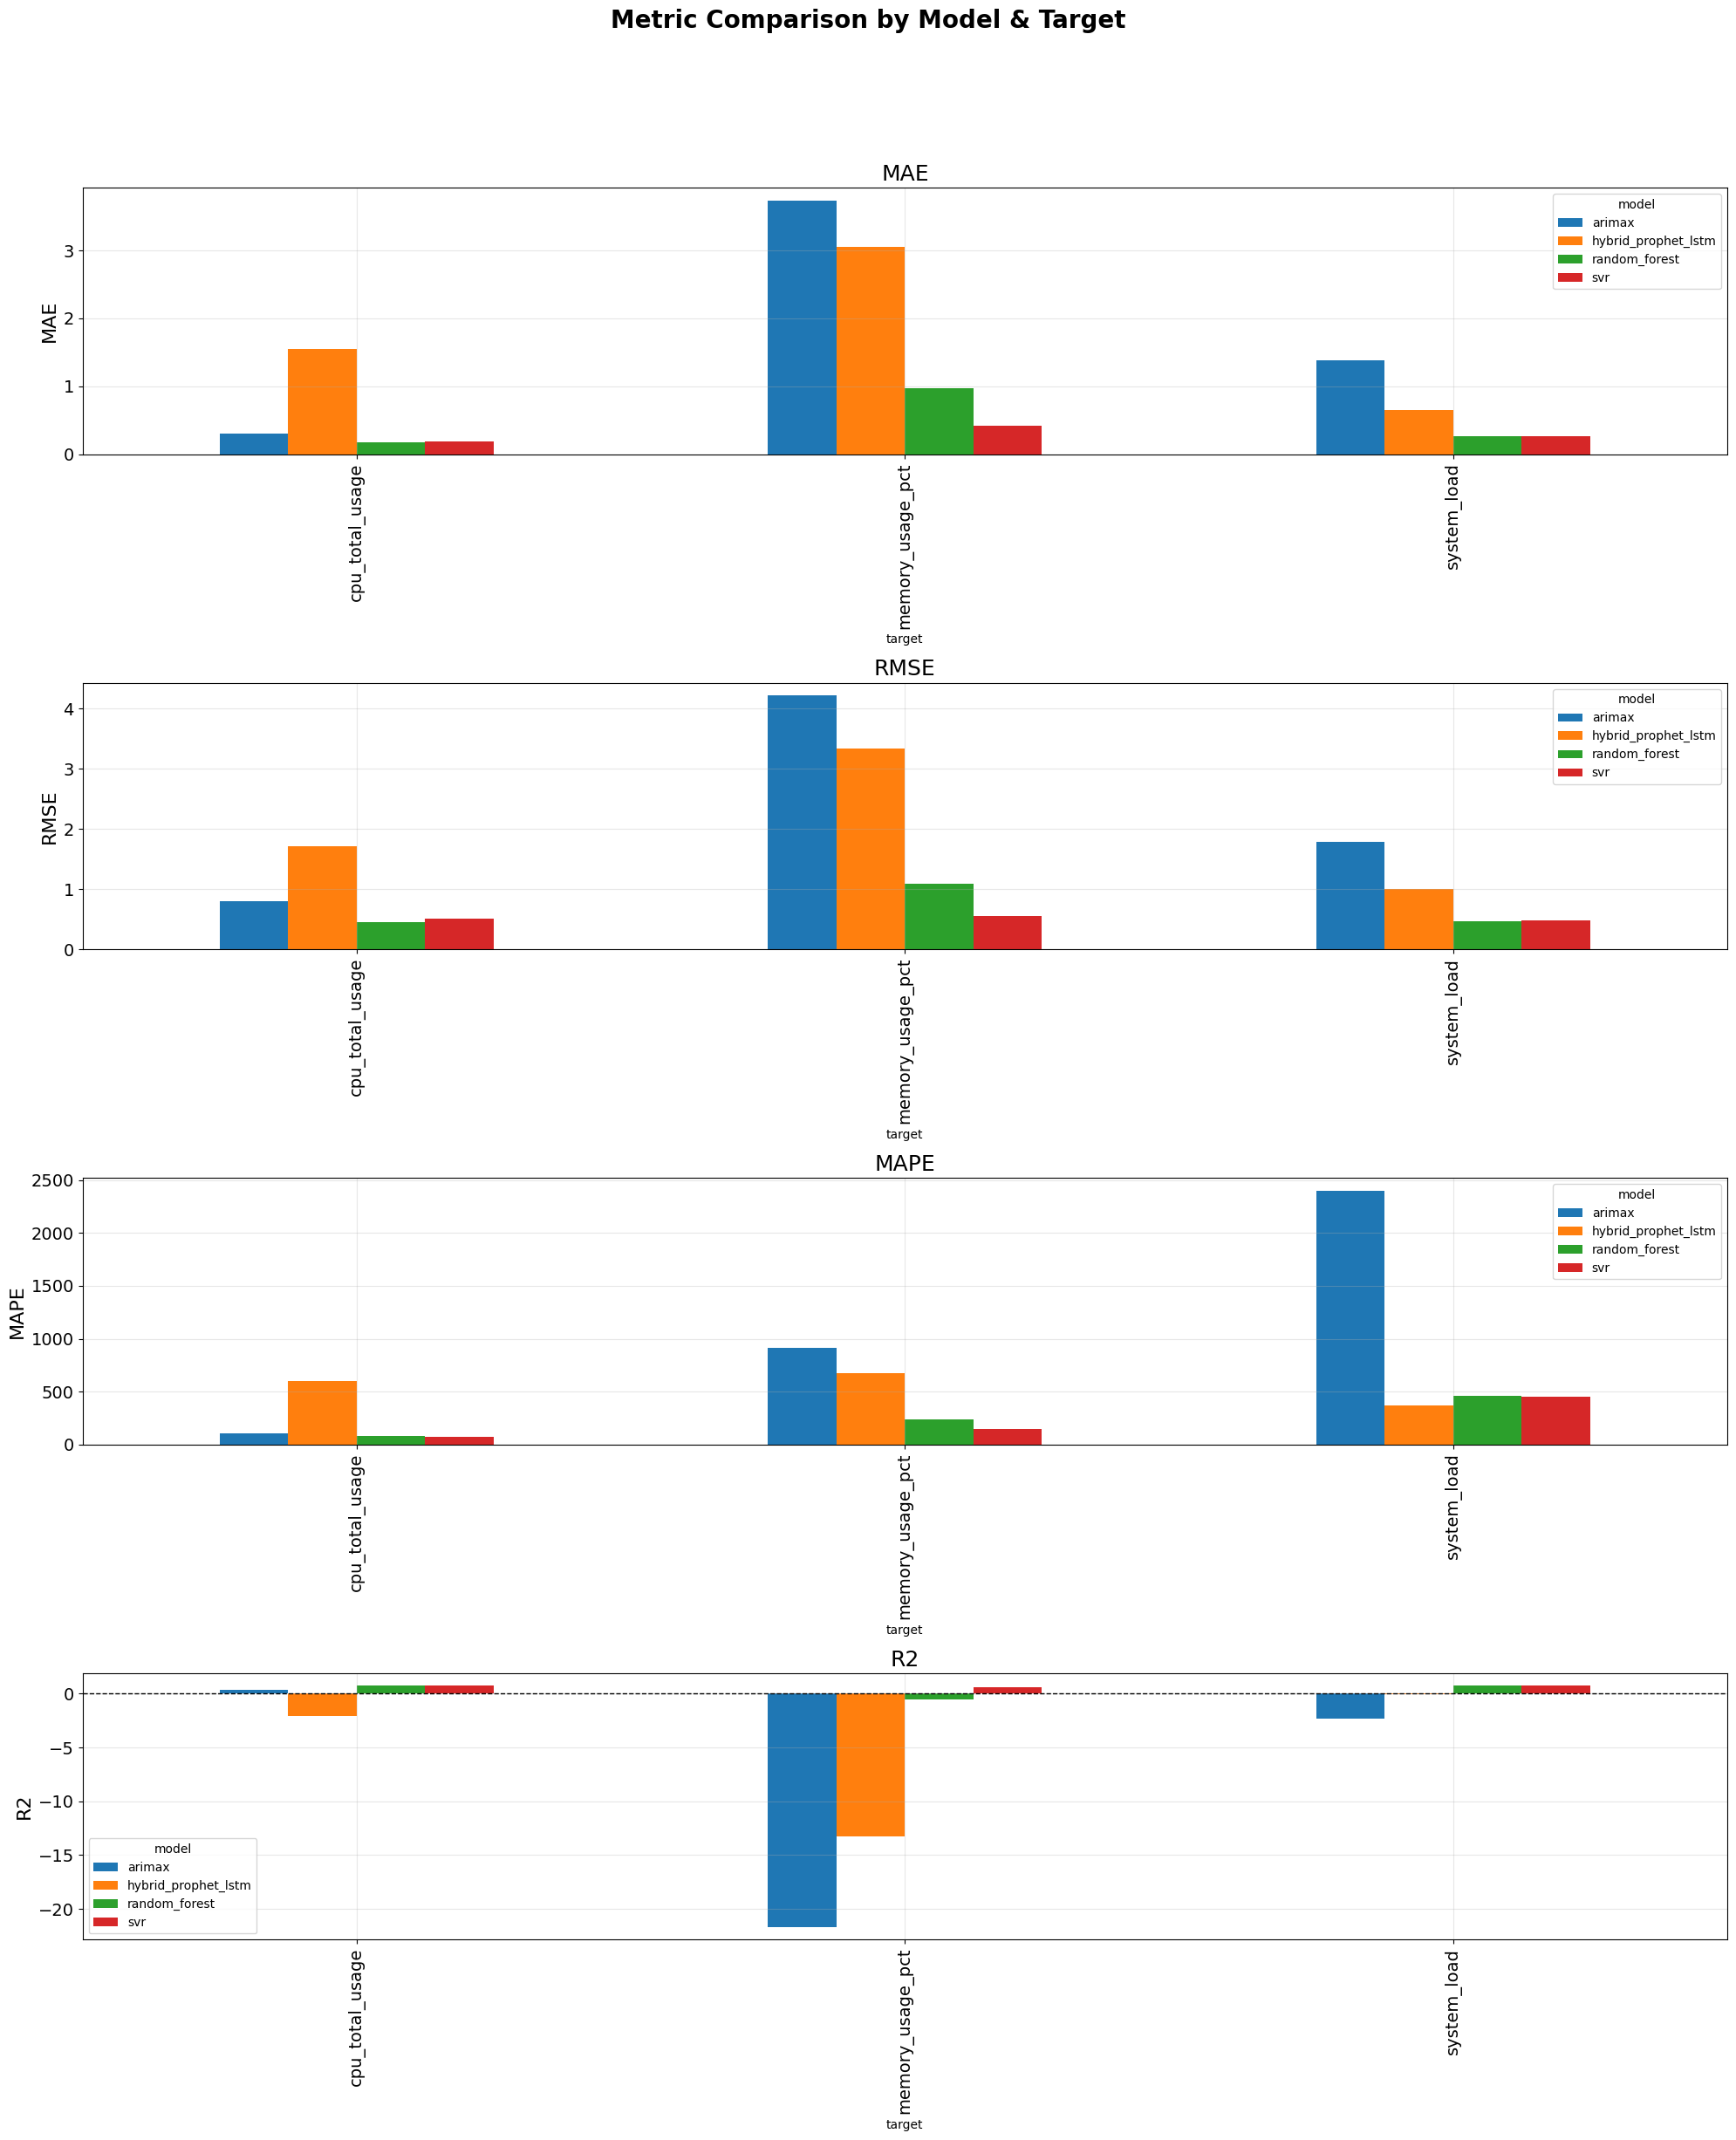

In [15]:
metrics_long = summary_df.reset_index()[['target', 'model', 'mae', 'rmse', 'mape', 'r2']]

metric_list = ['mae', 'rmse', 'mape', 'r2']
colors = ['#1e88e5', '#d81b60', '#43a047', '#ffb300']

fig, axes = plt.subplots(len(metric_list), 1, figsize=(20, 24))
fig.suptitle('Metric Comparison by Model & Target', fontsize=20, fontweight='bold', y=1.02)

for idx, (ax, metric, color) in enumerate(zip(axes, metric_list, colors)):
    pivot_df = metrics_long.pivot(index='target', columns='model', values=metric)
    pivot_df.plot(kind='bar', ax=ax, color=None)
    ax.set_title(metric.upper(), fontsize=18)
    ax.set_ylabel(metric.upper(), fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, alpha=0.3)
    if metric == 'r2':
        ax.axhline(y=0, color='k', linestyle='--', linewidth=1)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


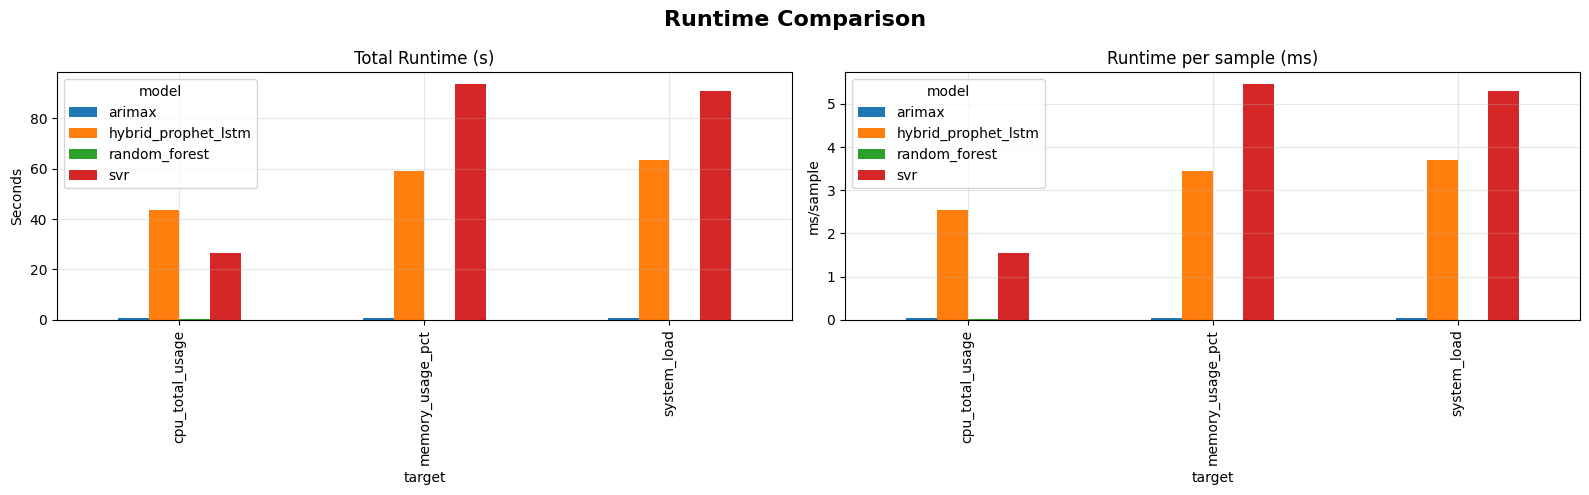

In [12]:
runtime_df = summary_df.reset_index()[['target', 'model', 'runtime_s', 'ms_per_sample']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Runtime Comparison', fontsize=16, fontweight='bold')

runtime_df.pivot(index='target', columns='model', values='runtime_s').plot(kind='bar', ax=axes[0])
axes[0].set_title('Total Runtime (s)')
axes[0].set_ylabel('Seconds')
axes[0].grid(True, alpha=0.3)

runtime_df.pivot(index='target', columns='model', values='ms_per_sample').plot(kind='bar', ax=axes[1])
axes[1].set_title('Runtime per sample (ms)')
axes[1].set_ylabel('ms/sample')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
results_payload = {
    'type': 'multi_model_inference',
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models': detailed_results,
    'summary': summary_df.reset_index().to_dict(orient='records'),
}

save_results(results_payload, 'results_multi_model_inference.json')


✓ Results saved: results_multi_model_inference.json


'results_multi_model_inference.json'